上节课咱们已经学习了大模型最核心的部分：多头注意力机制，这节课咱们将之前学习的知识点汇总起来实现大模型，为下节课训练大模型做准备。
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-1.png)

#### 4.1 Coding an LLM architecture
 ![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-2.png)

 大语言模型看似复杂，参数量众多，其实并不复杂，因为大部分组件都是重复的，参数量越大，重复的次数越多而已。我们接下来就详细讲下transformer block.并实现一个124M（1亿2千4百万）参数量的大模型(GPT2),GPT3大模型虽然没有开源，但其内部架构和原理还是一样的，主要是参数量扩大到175B，训练数据量更多之外，其他并没有太多变化。

 我们通过一个python字典来指定模型的参数。

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,#词典的单词个数
    "context_length":1024,#支持的上下文长度为1024
    "emb_dim": 768,# 嵌入式向量长度
    "n_heads":12,# 注意力头的个数
    "n_layers":12,# transformer block的个数
    "drop_rate":0.1,
    "qkv_bias":False
}

![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-3.png)

接下来先写GPT骨架代码

In [3]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )
    def forward(self,in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len,device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x

![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-4.png)

In [4]:
# 为了实现这些步骤，我们使用第二章中提到的tiktoken分词器，
# 对一个包含两条供GPT模型使用的文本输入的批次进行分词处理。
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:
# 初始化一个124M参数的DummyGPTModel实例
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:",logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


我们已经整体看了GPT架构的骨架，并且看了输入和输出，那么接下来开始真正实现那些Dummy的代码

#### 4.2 Normalizing activations with layer normalization
使用层归一化进行归一化

我们已经在上一节课里学过如何使用层归一化技术对结果进行处理，目的是让训练过程能够稳定和高效进行下去。层归一化技术是避免梯度过大或者过小。

层归一化背后的实质是将神经网络的输出结果进行调整到平均值为0，方差为1。在基于Transformer架构的大模型里，层归一化主要应用在多头注意力模块前后以及在最终输出层之前。

![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-5.png)

接下来我们实现上图的层归一化

In [6]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6),nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [7]:
mean = out.mean(dim=-1,keepdim=True)
var = out.var(dim=-1,keepdim=True)
print("Mean:\n",mean)
print("Variance:\n",var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [8]:
out_norm = (out-mean)/torch.sqrt(var)
mean = out_norm.mean(dim=-1,keepdim=True)
var = out_norm.var(dim=-1,keepdim=True)
print("Normalized layer outputs:\n",out_norm)
print("Mean:\n",mean)
print("Variance:\n",var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[2.9802e-08],
        [3.9736e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


In [9]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n",mean)
print("Variance:\n",var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


In [10]:
# 将上面的代码封装进PyTorch module里，方便后面使用
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)
        var = x.var(dim=-1,keepdim=True,unbiased=False)
        norm_x = (x-mean)/torch.sqrt(var+self.eps)
        return self.scale * norm_x + self.shift

In [11]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(keepdim=True,dim=-1)
var = out_ln.var(unbiased=False,keepdim=True,dim=-1)
print("Mean:\n",mean)
print("Variance:\n",var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-7.png)

#### 4.3 Implementing a feed forward network with GELU activation

接下来我们实现一个小的神经网络子模块用作transformer block的一部分。

先从实现GELU激活函数开始，我们之前使用的ReLU激活函数，在大模型里使用GELU进行替换。

ReLU激活函数在深度学习中使用非常广泛，因为其简单和效率高，但在大模型中，GELU(Gaussian error linear unit高斯误差线性单元)和SwiGLU(Swish-gated linear unit Swish门控线性单元)使用更广泛。

GELU（高斯误差线性单元）  
定义和公式：  
GELU 激活函数的精确形式定义为GELU(x) = x⋅𝛷(x)，其中𝛷(x)是标准高斯分布的累积分布函数。在实际应用中，为了降低计算成本，通常会采用近似计算。  
函数特点：  
它是一个平滑的非线性函数。与 ReLU 相比，GELU 对于几乎所有的负值（除了大约在处）都有非零梯度。这种平滑性在训练期间可以带来更好的优化特性，因为它允许对模型参数进行更细致的调整。  
例如，在反向传播过程中，非零梯度可以使梯度信息更有效地传递，有助于更新参数，特别是对于那些输入为负数的神经元。  
应用场景和优势：  
在大型语言模型（LLMs）等深度学习模型中得到应用。由于其能够更好地处理输入信号，特别是对于负输入也能有一定的响应，不像 ReLU 对负输入直接输出零，所以在模型训练过程中，接收负输入的神经元仍然可以对学习过程有所贡献，有助于模型学习到更复杂的模式，提高模型的性能。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/Equation-eqs-4.png)

In [12]:
# an implementation of the GELU activation function
# pytorch也提供了GELU方法，nn.GELU()
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (1+torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x+0.044715  * torch.pow(x,3))
        ))

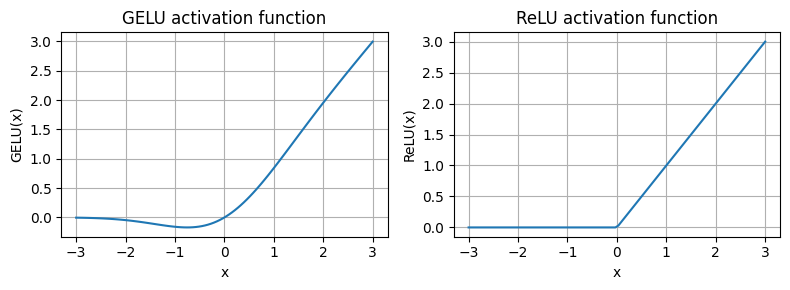

In [13]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3,3,100)
y_gelu,y_relu = gelu(x),relu(x)
plt.figure(figsize=(8,3))
for i,(y,label) in enumerate(zip([y_gelu,y_relu],["GELU","ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()


从上图可以看出，ReLU是分段式线性函数，如果x是正数，y和x一样，如果x是负数，y则是零。而GELU则是平滑，非线性函数，除了在x=-0.75外，其他地方梯度都不会是零。  
接下来我们使用GELU作为激活函数来实现FeedForward前馈方法。

In [14]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"],4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"],cfg["emb_dim"])
        )
    def forward(self,x):
        return self.layers(x)

![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-9.png)

In [15]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


这种先扩展、再非线性激活、最后收缩回原维度的设计，使得模型能够探索更丰富的表示空间。它突破了仅使用原始维度进行特征表示的局限，通过进入高维空间挖掘更多隐藏特征和关系，再将这些有价值的信息带回原始维度输出，让模型能够以更全面、更细致的方式对输入数据进行表征，进而更好地理解数据、学习数据中的模式，最终提升模型从数据中学习以及泛化到新数据的能力，有助于提升整个模型在各类任务（如文本生成、分类等）中的性能表现。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-10.png)  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-11.png)

#### 4.4 Adding shortcut connections  
shortcut connection又被称为residual connection。  
在 2015 年，何恺明等人在论文《Deep Residual Learning for Image Recognition》中介绍了残差网络（ResNet），残差网络的核心创新点就是引入了残差连接（shortcut connection）。这一技术解决了深度神经网络训练过程中的梯度消失和梯度爆炸问题，使得训练更深层次的网络成为可能，从而极大地提升了神经网络在图像识别等任务中的性能。  
这也是中国人在深度学习领域目前为止最厉害的贡献。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-12.png)  
上图显示shortcut connection(捷径连接)将一层的输出连接到下一层的输出上。这样可以避免梯度快速衰减。  
下面我们通过代码来展示如何实现shortcut connection

In [16]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self,layer_sizes,use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]),
                          GELU()),    
            nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]),
                          GELU())                                   
        ])
    def forward(self,x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = layer_output + x
            else:
                x = layer_output
        return x

上述代码有5层的神经网络，每一层包括一个线性层和GELU激活，在forward方法中，根据是否有shortcut connection，来决定是否将输入和下一层的输出进行相加。    
这里nn.ModuleList和nn.Sequential都是Module的容器，但作用不太一样，其中ModuleList的数据流动需要在forward方法里指定，灵活性比较高，比如这里forward方法里可以灵活控制是否有shortcut，而Sequential则是严格按照顺序进行流动的，灵活性差，但比较简单。  
接下来通过代码来实际看看有shortcut和无shortcut的情况下，梯度的情况  
首先咱们生成一个输入向量大小是3，最终输出向量大小是1的神经网络。

In [17]:
layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=False)
print(model_without_shortcut(sample_input).shape)

torch.Size([1, 1])


In [18]:
#实现一个方法来计算梯度
def print_gradients(model,x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output,target)

    loss.backward()

    for name, param in model.named_parameters():
        # print("name",name)
        # print("param",param)
        # print("abs",param.grad.abs())
        # print("mean",param.grad.abs().mean())

        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


In [19]:
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


从上面结果可以看到第0，1层的梯度非常小了，随着层数的越来越大，前面的层数在反向梯度传播时候，变得非常小了，也就是梯度消失，这种情况会导致训练无法收敛，或者训练速度很慢。  
那么接下来看添加shortcut connection后，其梯度如何：

In [20]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=True)
print_gradients(model_with_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


从上面可以看出，第0，1层的梯度变得并没有那么小了。  
接下来我们将上面所学的内容结合起来

#### 4.5 Connecting attention and linear layers in a transformer block
transformer block是GPT的最基础的代码模块，GPT的参数量增加就是靠不断增加transformer block的数量实现的，而transformer block就是由之前咱们介绍的组件组成的：multi-head attention,layer normalization,dropout,feed forward layers,GELU。这一节咱们将这些组件组合在一起形成transformer block，为下一节完全实现GPT打下基础。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-13.png)

根据上图，大家可以看出transformer block整体分为两部分，一部分是多头注意力机制，另外一部分是feed forward前馈网络层，这两部分入口都是经过层归一化处理，出口都是经过dropout，然后再加上shortcut connection.  
层归一化放在每一层的入口处，这种模式被称为Pre-LayerNorm，对应的还有一种是Post-LayerNorm，在传统的transformer架构中，应用的是Post-LayerNorm,实际训练中，Post-LayerNorm效率比较低下，目前多数采用Pre-LayerNorm。  
一方面，这样的组合能够让模型对输入数据有更细致入微的理解与处理。自注意力机制负责梳理元素之间的关系，挖掘其中的关联信息，而前馈网络则对每个位置的数据进行个性化的加工、优化，两者相互配合，使得模型可以从不同角度、不同层面去剖析输入数据，不放过数据中的各种细节以及内在联系，从而实现更加精细、准确地把握输入数据所包含的信息。  
另一方面，这种结合还增强了模型整体处理复杂数据模式的能力。复杂的数据模式往往包含了多层次的结构、各种非线性关系以及隐藏的特征等，单独依靠自注意力机制或者前馈网络可能都无法全面、有效地应对。但通过二者协同工作，模型就能更好地应对这些复杂情况，例如在自然语言处理任务中更准确地理解语义、语法，生成更合理的文本内容；在图像等其他领域也能更好地捕捉图像不同区域之间的关联以及特征变化等，进而提高模型在各类复杂任务中的性能表现。

In [21]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_out,d_out)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length,context_length),
                       diagonal=1)
        )
    def forward(self,x):
        b,num_tokens,d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # 将keys,queries,values转化为多头的模式
        keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
        queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)
        values = values.view(b,num_tokens,self.num_heads,self.head_dim)

        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # 这里注意keys的转置，因为第0维是批次
        attn_scores = queries @ keys.transpose(2,3)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens,:num_tokens],-torch.inf
        )
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,dim=-1
        )
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ values).transpose(1,2)
        # contiguous方法是将张量的数据在内存中是连续的，不然view方法就会报错
        context_vec = context_vec.contiguous().view(
            b,num_tokens,self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec


In [22]:
class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self,x):
        # 先经过多头注意力机制层
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = shortcut + x

        # 经过前馈网络层
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = shortcut + x

        return x

In [23]:
torch.manual_seed(123)
x = torch.rand(2,4,768)
block = TransformerBlock(GPT_CONFIG_124M)
out = block(x)

print("Input shape:",x.shape)
print("Output shape:",out.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


可以发现transformer block输入和输出的shape一样，并没有改变其大小。这种设计并不是偶然的，而是刻意设计的，这一设计利于其在众多序列到序列任务中有效应用，能维持输入输出向量一对一关系。其输出是包含整个输入序列信息的上下文向量，虽序列的物理维度在经过该架构时保持不变，但各输出向量内容经重新编码融入了上下文信息，提升了模型对序列数据的理解与处理能力。  
并且输入和输出保持一致可以让transformer block重叠使用，这也是大模型参数众多的原因之一。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-14.png)

#### 4.6 Coding the GPT model
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-15.png)  
上图是GPT模型的整体概览，接下来咱们就根据之前的组件组成大模型，图中所示Transformer block重复了12次。而拥有1542 百万参数的GPT-2模型重复了48次Transformer block.  最后一个transformer block的输出经过一个最终的层归一化，然后最终通过一个线性输出层对外输出。  
在开头咱们在DummyGPTModel里使用DummyTransformerBlock和DummyLayerNor，接下来使用真正的代码进行替代。

In [25]:
from torch import logit


class GPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )

    def forward(self,in_idx):
        batch_size,seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len,device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)

        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


我们会在下一小节将logits转化为token和text  
接下来咱们使用上述代码进行看下输出结果

In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n",batch)
print("\n Output shape:",out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

 Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


接下来看看这个模型的参数量

In [27]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters:{total_params:,}")

Total number of parameters:163,009,536


咱们之前一直说的是124 million，但这里为什么是163 million呢？  
原因是weight typing,这个概念是在GPT-2模型里，意思是将token embedding的参数用在输出层。咱们来看看这两层的参数量

In [28]:
print("Token embedding layer shape:",model.tok_emb.weight.shape)
print("Output layer shape:",model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [29]:
total_params_gpt2 = (total_params - sum(
    p.numel() for p in model.out_head.parameters()
))
print(f"Number of trainable parameters considering weight typing:{total_params_gpt2:,}")

Number of trainable parameters considering weight typing:124,412,160


可以看出确实是124 million参数量，GPT-2之所以使用这个技术，是因为想节约内存和计算量，不过在当代大模型里，不再复用参数，因为效果不太好。

In [30]:
# 看看163 million参数量的内存量
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model:{total_size_mb:.2f}")

Total size of the model:621.83


#### 4.7 Generating text
我们开始将模型的输出如何从数字转化为文字  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-16.png)  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-17.png)

In [36]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:,-1,:]
        probas = torch.softmax(logits,dim=-1)
        idx_next = torch.argmax(probas,dim=-1,keepdim=True)
        idx = torch.cat((idx,idx_next),dim=1)
    return idx

上面代码softmax是将logits转化为概率，argmax是获取概率最大的索引值，由于softmax是单调函数，这里可以不用softmax，但为了展示过程，这里还是使用了softmax，实际代码中可以不用的，这种方式称为greedy decoding（贪婪解码）。  
在下一章讲解如何训练时候，我们还会使用非argmax方法来获取索引值，目的是获取多样性。  
![](https://drek4537l1klr.cloudfront.net/raschka/Figures/4-18.png)  
接下来咱们来实际展示下效果

In [35]:
start_context = "Hello,I am"
encoded = tokenizer.encode(start_context)
print("encoded:",encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:",encoded_tensor.shape)

encoded: [15496, 11, 40, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [38]:
model.eval()
out = generate_text_simple(
    model=model,
    idx = encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:",out)
print("output length:",len(out[0]))

Output: tensor([[15496,    11,    40,   716, 27018,  7283, 46275, 11472, 21692, 43530]])
output length: 10


In [39]:
#使用tokenizer的decode方法可以将IDs转回text
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello,I am Feature IT snowball shocked merits neocons
